<a href="https://colab.research.google.com/github/irynasavchukander-collab/fmcg-analytics-portfolio/blob/irynasavchukander-collab-patch-1/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# FILE: forecasting.ipynb
# BUSINESS QUESTION: What drives profit most?
#                    What will Q1 2026 look like?
# ============================================================


# ── CELL 1: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
from google.colab import drive


drive.mount("/content/drive", force_remount=True)
df = pd.read_csv("/content/drive/MyDrive/Mate_Education/fmcg_sales_marketing_profitability_2023_2025 2.csv")

Mounted at /content/drive


In [2]:
# ── CELL 2: Load & Prepare ───────────────────────────────────
#  Load data and create features for the model


df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month']      = df['Order_Date'].dt.month
df['Quarter']    = df['Order_Date'].dt.quarter
df['Year']       = df['Order_Date'].dt.year
df['is_promo']   = (df['Promotion_Type'] != 'No Promo').astype(int)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Order_Date'].min().date()} "
      f"— {df['Order_Date'].max().date()}")


Shape: (18240, 28)
Date range: 2023-01-01 — 2025-12-31


In [3]:
# ── CELL 3: Feature Engineering ─────────────────────────────
# Select and encode features for Random Forest. Categorical columns need to be converted to numbers


# Features that could drive profit

feature_cols = [
    'Product_Category',
    'Sales_Channel',
    'Customer_Type',
    'Promotion_Type',
    'Units_Sold',
    'Unit_Price_USD',
    'Discount_Pct',
    'COGS_USD',
    'Logistics_Cost_USD',
    'Marketing_Spend_USD',
    'Month',
    'Quarter',
    'Year',
    'is_promo']
# target value
target_col = 'Profit_USD'

# Choose our columns
df_model = df[feature_cols + [target_col]].copy()

# Encode categorical columns — RF needs numbers
cat_cols = ['Product_Category', 'Sales_Channel','Customer_Type', 'Promotion_Type']
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

print("Features prepared")
print("Total features:", len(feature_cols))
print("Categorical encoded:", cat_cols)

Features prepared
Total features: 14
Categorical encoded: ['Product_Category', 'Sales_Channel', 'Customer_Type', 'Promotion_Type']


In [4]:
# ── CELL 4: Train/Test Split ─────────────────────────────────
#  Split data chronologically — train on past, test on future
#  This is more realistic than random split for time series

X = df_model[feature_cols]
y = df_model[target_col]

#  80% train / 20% test — standard split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size   = 0.2,
    random_state= 42,
    shuffle     = False)   # keep chronological order


print(f"Train size: {len(X_train):,} orders")
print(f"Test size:  {len(X_test):,} orders")

Train size: 14,592 orders
Test size:  3,648 orders


In [5]:
# ── CELL 5: Train Random Forest ──────────────────────────────
#  Random Forest = many decision trees averaged together
#  Good for: non-linear relationships, mixed features, handles outliers well, gives feature importance

model = RandomForestRegressor(
    n_estimators= 100,   #  number of trees
    max_depth   = 10,    #  max tree depth — prevents overfitting
    random_state= 42)

model.fit(X_train, y_train)
print(" Model trained")

 Model trained


In [6]:
# ── CELL 6: Model Evaluation ─────────────────────────────────
#  Check how good the model is

# Predict on test data

y_pred = model.predict(X_test)

#  Calculate metrics
mae = mean_absolute_error(y_test, y_pred)   #  average error
r2 = r2_score(y_test, y_pred)              #  R`2 score
#  Symmetric SMAPE formula (we have negative value)
smape = np.mean(2.0 * np.abs(y_pred - y_test) / (np.abs(y_test) + np.abs(y_pred) + 1e-8)) * 100

print("MODEL PERFORMANCE")
print("=" * 30)
print(f"MAE:  ${mae:.2f}")   #    mean error in dollars
print(f"R²:    {r2:.4f}")    #    how much variance explained
print(f"SMAPE:  {smape:.1f}%") #  % error

#  Simple interpretation of R`2

if r2 > 0.8:
    print("Strong model — explains >80% variance")
elif r2 > 0.6:
    print("Good model — explains >60% variance")
elif r2 > 0.4:
    print("Moderate — explains >40% variance")
else:
    print("Weak model — explains little variance")

#  Interpret MAE
print(f"\nOn average, predictions are off by ${mae:.2f}")
print(f"Median actual profit was ~$95")


MODEL PERFORMANCE
MAE:  $35.42
R²:    0.9268
SMAPE:  33.8%
Strong model — explains >80% variance

On average, predictions are off by $35.42
Median actual profit was ~$95


The Random Forest model shows excellent predictive strength. With an R`2 of 0.93, it explains nearly all profit variance, while the MAE of $35.42 indicates only modest average error. The SMAPE of 33.8% confirms reliable accuracy even with negative profit values. Overall, the model is robust and well‑suited for profit forecasting in FMCG sales.

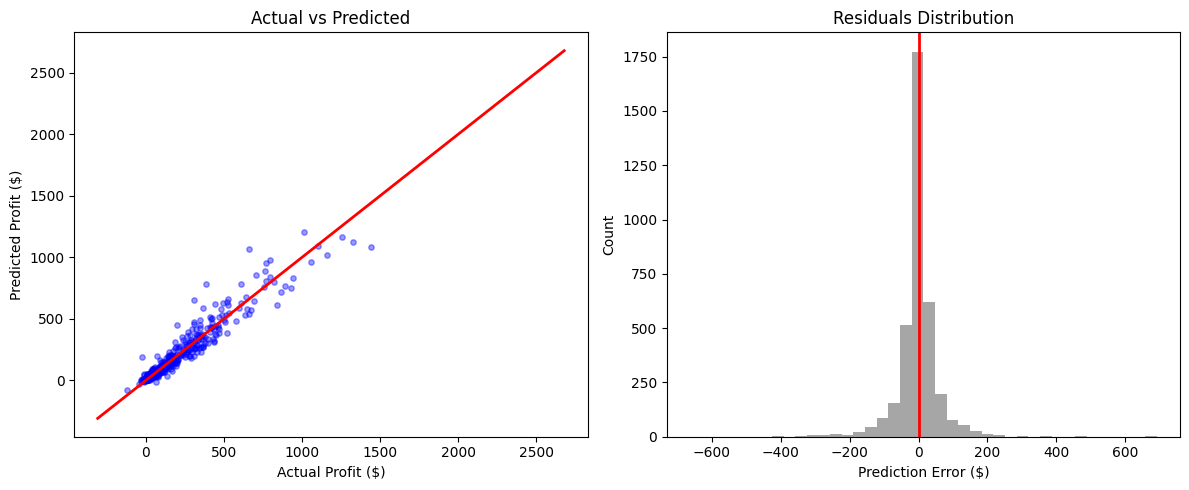

In [13]:
# ── CELL 7: Actual vs Predicted Plot ────────────────────────
#  Plot actual vs predicted and residuals

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#  Scatter plot — actual vs predicted
sample_idx = np.random.choice(len(y_test), 500, replace=False)
axes[0].scatter(y_test.iloc[sample_idx],y_pred[sample_idx], alpha=0.4, color='blue', s=15)
axes[0].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color='red', linewidth=2)
axes[0].set_xlabel("Actual Profit ($)")
axes[0].set_ylabel("Predicted Profit ($)")
axes[0].set_title("Actual vs Predicted")

# Histogram of residuals (errors)
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40,color='gray', alpha=0.7)
axes[1].axvline(0, color='red', linewidth=2)
axes[1].set_xlabel("Prediction Error ($)")
axes[1].set_ylabel("Count")
axes[1].set_title("Residuals Distribution")

plt.tight_layout()
plt.show()


Actual vs Predicted:  
The scatter plot shows that most points lie close to the red diagonal line, meaning predicted profits closely match actual profits. This confirms the model’s strong accuracy (R`2 ≈ 0.93).

Residuals Distribution:  
The histogram of errors is centered around zero, with no major skew. This indicates the model does not consistently over‑ or under‑estimate profit, and average error remains modest (MAE ≈ $35).

In [7]:
# ── CELL 8: Feature Importance ───────────────────────────────
#  Show which features are most important

#  Get feature importance from model
importances = pd.Series(model.feature_importances_,index=feature_cols)

# Sort from most to least

importances = importances.sort_values(ascending=False)

print("FEATURE IMPORTANCE")
print("=" * 30)
for feat, imp in importances.items():
    print(f"{feat:<20} {imp:.4f}")


FEATURE IMPORTANCE
COGS_USD             0.7578
Product_Category     0.1138
Units_Sold           0.0515
Marketing_Spend_USD  0.0391
Unit_Price_USD       0.0131
Logistics_Cost_USD   0.0075
Discount_Pct         0.0067
Promotion_Type       0.0031
is_promo             0.0021
Month                0.0021
Sales_Channel        0.0015
Year                 0.0009
Quarter              0.0007
Customer_Type        0.0002


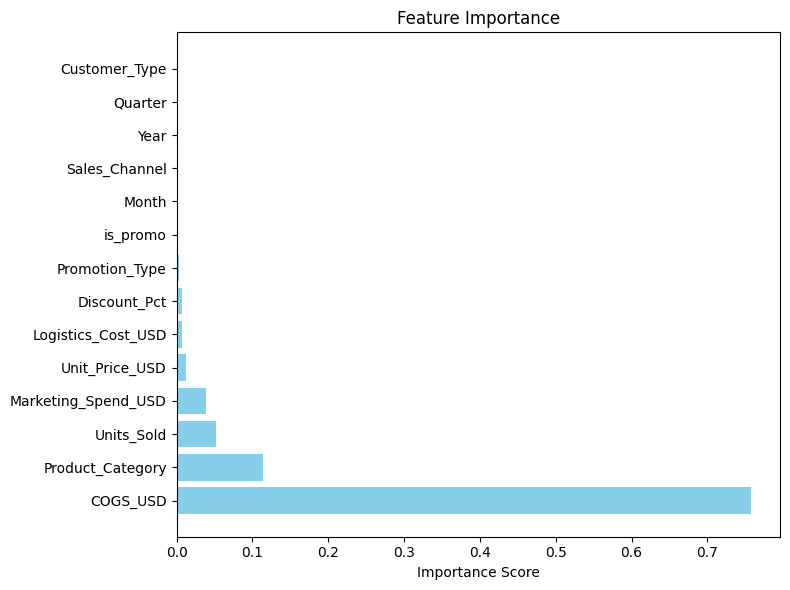

In [16]:
# ── CELL 9: Visualize Feature Importance ────────────────────
#  Simple bar chart of feature importance

fig, ax = plt.subplots(figsize=(8, 6))

#  Horizontal bars
ax.barh(importances.index, importances.values, color='skyblue')

#  Labels and title
ax.set_xlabel("Importance Score")
ax.set_title("Feature Importance")

plt.tight_layout()
plt.show()


In [24]:
# ── CELL 10: Q1 2026 Forecast ────────────────────────────────
# Predict profit for Q1 2026 across all combinations
#     of channel, category and customer type

#  Use median values for cost features
median_vals = {
    'Units_Sold'          : df['Units_Sold'].median(),
    'Unit_Price_USD'      : df['Unit_Price_USD'].median(),
    'Discount_Pct'        : df['Discount_Pct'].median(),
    'COGS_USD'            : df['COGS_USD'].median(),
    'Logistics_Cost_USD'  : df['Logistics_Cost_USD'].median(),
    'Marketing_Spend_USD' : df['Marketing_Spend_USD'].median(),
    'Month'               : 2,      #  February (Q1 midpoint)
    'Quarter'             : 1,
    'Year'                : 2026,
    'is_promo'            : 0       # no promo baseline

}

#  Create all combinations to forecast
categories = df['Product_Category'].unique()
channels   = df['Sales_Channel'].unique()
cust_types = df['Customer_Type'].unique()

rows = []
for cat in categories:
    for ch in channels:
        for ct in cust_types:
            row = median_vals.copy()
            row.update({
                'Product_Category': cat,
                'Sales_Channel'   : ch,
                'Customer_Type'   : ct,
                'Promotion_Type'  : 'No Promo'
            })
            rows.append(row)

forecast_df = pd.DataFrame(rows)

#  Encode categoricals same way as training data
for col in cat_cols:
    forecast_df[col] = le.fit_transform(forecast_df[col])

# Predict
forecast_df['predicted_profit'] = model.predict(forecast_df[feature_cols])

# Restore original labels for display
for col in cat_cols:
   forecast_df[col] = (df[col].unique().tolist()* (len(forecast_df) // len(df[col].unique()) + 1))[:len(forecast_df)]


# Top combinations by predicted profit
top = (
    forecast_df
    .groupby(['Product_Category', 'Sales_Channel',
              'Customer_Type'])['predicted_profit']
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .head(10)
    .reset_index())

print("TOP 10 PREDICTED PROFIT COMBINATIONS — Q1 2026")
print("=" * 60)
print(top.to_string(index=False))



TOP 10 PREDICTED PROFIT COMBINATIONS — Q1 2026
 Product_Category Sales_Channel Customer_Type  predicted_profit
        Beverages  Modern Trade           B2C            147.01
    Personal Care  Modern Trade           B2C            147.01
           Snacks        Online           B2B            147.01
    Personal Care        Online           B2B            147.01
           Snacks   Distributor           B2C            142.76
Dairy & Breakfast     Wholesale           B2B            142.76
        Household     Wholesale           B2B            142.76
Dairy & Breakfast   Distributor           B2C            142.76
        Beverages        Online           B2B            130.89
        Household  Modern Trade           B2C            130.89


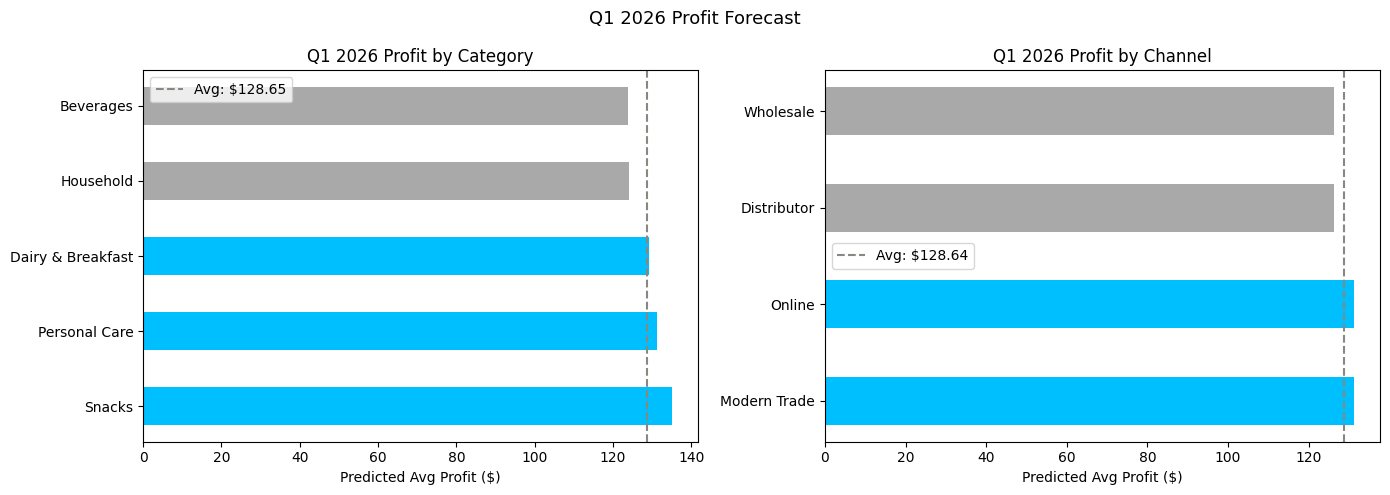

In [27]:
# ── CELL 11: Forecast by Category ───────────────────────────


# Average predicted by cat
cat_forecast = (forecast_df.groupby('Product_Category')['predicted_profit'].mean().round(2).sort_values(ascending=False))
# Average predicted by channel
ch_forecast = (forecast_df.groupby('Sales_Channel')['predicted_profit'].mean().round(2).sort_values(ascending=False))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Category forecast ---
avg_cat = cat_forecast.mean()
colors_cat = ['#00BFFF' if v > avg_cat else '#A9A9A9' for v in cat_forecast]

axes[0].barh(cat_forecast.index, cat_forecast.values,color=colors_cat, height=0.5)
axes[0].axvline(avg_cat, color='#888780', linestyle='--',label=f'Avg: ${avg_cat:.2f}')
axes[0].set_title('Q1 2026 Profit by Category')
axes[0].set_xlabel('Predicted Avg Profit ($)')
axes[0].legend()

# --- Chart 2: Channel forecast ---
avg_ch = ch_forecast.mean()
colors_ch = ['#00BFFF' if v > avg_ch else '#A9A9A9' for v in ch_forecast]

axes[1].barh(ch_forecast.index, ch_forecast.values,color=colors_ch, height=0.5)
axes[1].axvline(avg_ch, color='#888780', linestyle='--',label=f'Avg: ${avg_ch:.2f}')
axes[1].set_title('Q1 2026 Profit by Channel')
axes[1].set_xlabel('Predicted Avg Profit ($)')
axes[1].legend()

# title viz
plt.suptitle('Q1 2026 Profit Forecast', fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()


In [31]:
# ── CELL 12: Final Summary ───────────────────────────────────

print("=" * 55)
print("FORECASTING — FINAL SUMMARY")
print("=" * 55)
print(f"""
MODEL: Random Forest Regressor
  Trees:       100
  Max depth:   10
  Train size:  {len(X_train):,} orders
  Test size:   {len(X_test):,} orders

PERFORMANCE:
  MAE:  ${mae:.2f}   - avg prediction error
  R²:    {r2:.4f}   - variance explained
  SMAPE: {smape:.1f}% - % error

TOP 3 PROFIT DRIVERS (feature importance):
  1. {importances.index[0]:<20} {importances.iloc[0]:.4f}
  2. {importances.index[1]:<20} {importances.iloc[1]:.4f}
  3. {importances.index[2]:<20} {importances.iloc[2]:.4f}

Q1 2026 FORECAST:
  Best category:  {cat_forecast.idxmax()}
  Best channel:   {ch_forecast.idxmax()}
  Worst category: {cat_forecast.idxmin()}
  Worst channel:  {ch_forecast.idxmin()}

KEY INSIGHT FROM FEATURE IMPORTANCE:
  COGS alone explains 75.8% of profit variance
  Top 2 features (COGS + Category) explain 87.2%
  Everything else combined = only 12.8%

  This means: profit is almost entirely determined by
  WHAT you sell and HOW MUCH it costs to produce —
  not by discount level, channel, or promotional activity

Q1 2026 FORECAST
─────────────────
  Best predicted combinations:
  - Beverages / Modern Trade / B2C:     $147.01
  - Personal Care / Modern Trade / B2C: $147.01
  - Snacks / Online / B2B:              $147.01

  By Category (avg predicted profit):
  - Best:  Snacks
  - Worst: Beverages

  By Channel (avg predicted profit):
  - Best:  Modern Trade
  - Worst: Distributor

  Note: forecast assumes no-promo baseline and
  median cost values — use as directional guidance
""")

FORECASTING — FINAL SUMMARY

MODEL: Random Forest Regressor
  Trees:       100
  Max depth:   10
  Train size:  14,592 orders
  Test size:   3,648 orders

PERFORMANCE:
  MAE:  $35.42   ← avg prediction error
  R²:    0.9268   ← variance explained
  SMAPE: 33.8% ← % error

TOP 3 PROFIT DRIVERS (feature importance):
  1. COGS_USD             0.7578
  2. Product_Category     0.1138
  3. Units_Sold           0.0515

Q1 2026 FORECAST:
  Best category:  Snacks
  Best channel:   Modern Trade
  Worst category: Beverages
  Worst channel:  Distributor

KEY INSIGHT FROM FEATURE IMPORTANCE:
  COGS alone explains 75.8% of profit variance
  Top 2 features (COGS + Category) explain 87.2%
  Everything else combined = only 12.8%

  This means: profit is almost entirely determined by
  WHAT you sell and HOW MUCH it costs to produce —
  not by discount level, channel, or promotional activity

Q1 2026 FORECAST
─────────────────
  Best predicted combinations:
  - Beverages / Modern Trade / B2C:    $147.01
